# C0 performance — 5 CheXpert competition tasks

Multi-label DenseNet121, U-Ignore, evaluated on `C2_dataset` (95,835 frontal images
the model never saw). Uncertain (`-1`) rows are excluded per task.

In [1]:
import os
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve

FE = '/zhome/d0/a/221493/thesis/final_experiment'
RESULTS = os.environ.get('THESIS_RESULTS', '/work3/s251710/thesis_results')
MODEL_DIR = f'{RESULTS}/C0_final/multilabel_ignore'

TASKS = ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Pleural Effusion']
COLORS = ['#0072B2', '#009E73', '#D55E00', '#CC79A7', '#E69F00']
# CheXpert column name -> the per-disease output dir the pipeline writes
DIR = {'Atelectasis': 'atelectasis', 'Cardiomegaly': 'cardiomegaly',
       'Consolidation': 'consolidation', 'Edema': 'edema',
       'Pleural Effusion': 'effusion'}

# Read each task from ITS OWN pipeline output -- the same
# C2_dataset_c0_<disease>.csv that C2 trains on, and the same threshold.txt that
# defines `correct` there.
#
# This used to pull every task's probabilities out of the effusion directory's
# all_probs file and recompute Youden's J here. The backbone is one 14-logit
# model, so that is *nearly* equivalent -- but two inference runs differ at the
# 1e-4 level (cuDNN algorithm choice, batch composition), and Youden's J is a
# flat argmax: for cardiomegaly ~40 thresholds spanning 0.16-0.22 sit within
# 0.002 of the optimum. Those 1e-4 wiggles were enough to move the reported
# threshold from 0.1598 (what the pipeline froze and every downstream artifact
# uses) to 0.2070 (what this figure showed). Same formula, same split, different
# point on a plateau.
#
# Reading the frozen files removes the recomputation, so the figure matches the
# operating point behind `correct`, the C2 folds, the CF level endpoints and the
# Grad-CAM orientation by construction rather than by luck.
data, YOUDEN, N_UNCERTAIN = {}, {}, {}
for t in TASKS:
    d = DIR[t]
    df = pd.read_csv(f'{MODEL_DIR}/{d}/C2_dataset_c0_{d}.csv',
                     usecols=['path', 'prob', 'true', 'certain'])
    YOUDEN[t] = float(open(f'{MODEL_DIR}/{d}/threshold.txt').read().split()[0])
    # U-Ignore: uncertain (-1) rows were masked out of C0's loss and carry
    # true = NaN. They have no ground truth, so they are excluded per task.
    keep = (df['certain'] == 1) & df['true'].notna()
    N_UNCERTAIN[t] = int((~keep).sum())
    data[t] = (df.loc[keep, 'true'].values, df.loc[keep, 'prob'].values)

n_total = len(pd.read_csv(f'{MODEL_DIR}/effusion/C2_dataset_c0_effusion.csv',
                          usecols=['path']))
print(f'{n_total:,} images in C2_dataset')
print('frozen operating points (threshold.txt, as used downstream):')
for t in TASKS:
    print(f'   {t:18s} {YOUDEN[t]:.4f}   n={len(data[t][0]):,}  '
          f'uncertain={N_UNCERTAIN[t]:,}')

95,835 images in C2_dataset
frozen operating points (threshold.txt, as used downstream):
   Atelectasis        0.1886   n=80,946  uncertain=14,889
   Cardiomegaly       0.1598   n=92,515  uncertain=3,320
   Consolidation      0.0671   n=83,697  uncertain=12,138
   Edema              0.2849   n=89,862  uncertain=5,973
   Pleural Effusion   0.3932   n=90,943  uncertain=4,892


## Summary

In [2]:
rows = []
for t in TASKS:
    y, p = data[t]
    rows.append({'task': t, 'AUC': roc_auc_score(y, p), 'n': len(y),
                 'positive %': 100 * y.mean(), 'uncertain': N_UNCERTAIN[t],
                 'threshold': YOUDEN[t],
                 'mean p | pos': p[y == 1].mean(), 'mean p | neg': p[y == 0].mean()})
summary = pd.DataFrame(rows).set_index('task')
summary.round(3)

,AUC,n,positive %,uncertain,threshold,mean p | pos,mean p | neg
task,,,,,,,
Atelectasis,0.715,80946,18.637,14889,0.189,0.300,0.191
Cardiomegaly,0.867,92515,12.496,3320,0.160,0.452,0.101
Consolidation,0.736,83697,7.809,12138,0.067,0.126,0.069
Edema,0.847,89862,27.766,5973,0.285,0.535,0.202
Pleural Effusion,0.884,90943,42.214,4892,0.393,0.706,0.238


## ROC

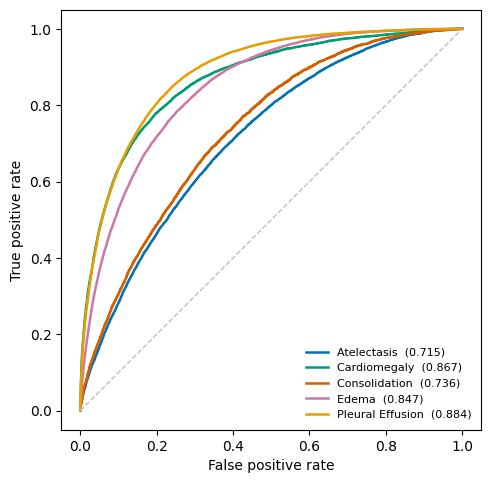

In [3]:
fig, ax = plt.subplots(figsize=(5, 5))
for t, c in zip(TASKS, COLORS):
    y, p = data[t]
    fpr, tpr, _ = roc_curve(y, p)
    ax.plot(fpr, tpr, color=c, lw=1.8, label=f'{t}  ({roc_auc_score(y, p):.3f})')
ax.plot([0, 1], [0, 1], color='#BFBFBF', ls='--', lw=1)
ax.set_xlabel('False positive rate'); ax.set_ylabel('True positive rate')
ax.legend(fontsize=8, frameon=False, loc='lower right')
ax.set_aspect('equal'); plt.tight_layout()

## Where the predictions land

Predicted probability split by ground truth. Density (not count) so the two
classes are comparable despite very different prevalence. The dashed line is the
per-task Youden-J operating point; 0.5 sits far to the right of it on every task,
which is why the naive threshold almost never predicts positive.


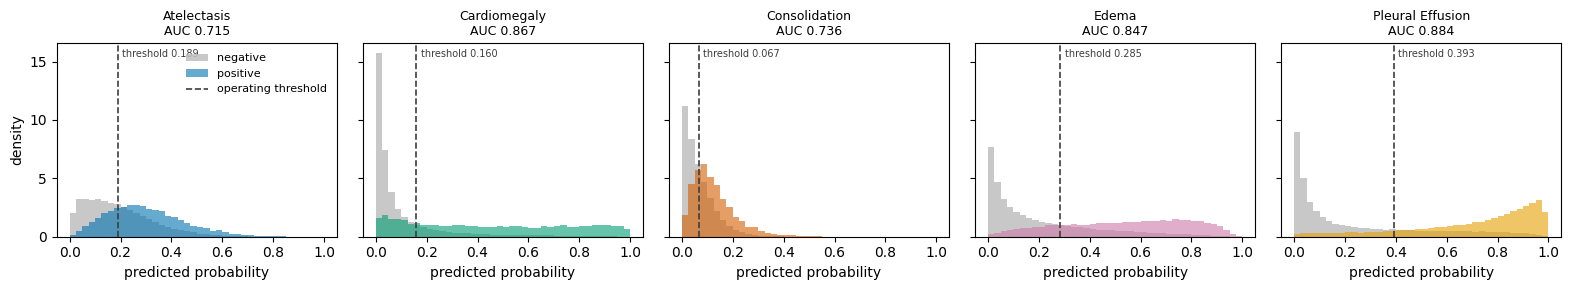

In [4]:
fig, axes = plt.subplots(1, 5, figsize=(16, 3), sharey=True)
bins = np.linspace(0, 1, 41)
for ax, t, c in zip(axes, TASKS, COLORS):
    y, p = data[t]
    ax.hist(p[y == 0], bins=bins, density=True, color='#BFBFBF', alpha=.85, label='negative')
    ax.hist(p[y == 1], bins=bins, density=True, color=c, alpha=.6, label='positive')
    ax.axvline(YOUDEN[t], color='#3D3D3D', ls='--', lw=1.2, zorder=5)
    # 3 decimals: 2 rounds 0.1598 and 0.2070 to "0.16"/"0.21" and hides that the
    # Youden objective is flat across that whole band.
    ax.annotate(f'threshold {YOUDEN[t]:.3f}', xy=(YOUDEN[t], 1), xycoords=('data', 'axes fraction'),
                xytext=(3, -4), textcoords='offset points', ha='left', va='top',
                fontsize=7, color='#3D3D3D')
    ax.set_title(f'{t}\nAUC {roc_auc_score(y, p):.3f}', fontsize=9)
    ax.set_xlabel('predicted probability')
axes[0].set_ylabel('density')
h, l = axes[0].get_legend_handles_labels()
h.append(plt.Line2D([], [], color='#3D3D3D', ls='--', lw=1.2)); l.append('operating threshold')
axes[0].legend(h, l, fontsize=8, frameon=False)
plt.tight_layout()

## Correct vs incorrect predictions

What C2 actually has to work with: how many decisions C0 gets right, and how the
errors split into false negatives (missed findings) and false positives.

Two operating points, because the answer depends entirely on the threshold:
`0.5` (the naive rule) and the per-task Youden-J point, which is chosen on the
held-out **checkpoint-selection** set, never on `C2_dataset` itself.


In [5]:
THR_SETS = {'0.5': {t: 0.5 for t in TASKS}, 'operating': YOUDEN}

def confusion(thr_set):
    rows = []
    for t in TASKS:
        y, p = data[t]
        # `>` not `>=`, matching apply_threshold() in c0_final_predictions.py --
        # otherwise this table disagrees with the `correct` column C2 trains on.
        yh = (p > thr_set[t]).astype(int)
        tp = int(((yh == 1) & (y == 1)).sum()); fp = int(((yh == 1) & (y == 0)).sum())
        fn = int(((yh == 0) & (y == 1)).sum()); tn = int(((yh == 0) & (y == 0)).sum())
        rows.append({'task': t, 'threshold': thr_set[t], 'n': len(y),
                     'TN': tn, 'TP': tp, 'FN': fn, 'FP': fp,
                     'correct': tn + tp, 'incorrect': fn + fp,
                     'accuracy': (tn + tp) / len(y), 'error %': 100 * (fn + fp) / len(y)})
    return pd.DataFrame(rows).set_index('task')

conf = {k: confusion(v) for k, v in THR_SETS.items()}

# Cross-check against the `correct` column the pipeline actually wrote: this
# table is only meaningful if it reproduces what C2 sees.
print('accuracy here vs. the pipeline\'s own `correct` column:')
for t in TASKS:
    d = DIR[t]
    chk = pd.read_csv(f'{MODEL_DIR}/{d}/C2_dataset_c0_{d}.csv',
                      usecols=['correct', 'certain', 'true'])
    chk = chk[(chk['certain'] == 1) & chk['true'].notna()]
    got, exp = conf['operating'].loc[t, 'accuracy'], chk['correct'].mean()
    flag = 'ok' if abs(got - exp) < 1e-9 else 'MISMATCH'
    print(f'   {t:18s} {got:.6f} vs {exp:.6f}   {flag}')

pd.concat(conf, names=['operating point']).round(3)

accuracy here vs. the pipeline's own `correct` column:
   Atelectasis        0.594631 vs 0.594631   ok
   Cardiomegaly       0.810290 vs 0.810290   ok
   Consolidation      0.611288 vs 0.611288   ok
   Edema              0.748303 vs 0.748303   ok
   Pleural Effusion   0.794421 vs 0.794421   ok


threshold      n     TN     TP     FN  \
operating point task                                                      
0.5             Atelectasis           0.500  80946  64170   1593  13493   
                Cardiomegaly          0.500  92515  77547   5058   6503   
                Consolidation         0.500  83697  77151     13   6523   
                Edema                 0.500  89862  57290  14250  10701   
                Pleural Effusion      0.500  90943  42410  30566   7825   
operating       Atelectasis           0.189  80946  36828  11305   3781   
                Cardiomegaly          0.160  92515  66183   8781   2780   
                Consolidation         0.067  83697  46312   4851   1685   
                Edema                 0.285  89862  47231  20013   4938   
                Pleural Effusion      0.393  90943  39286  32961   5430   

                                     FP  correct  incorrect  accuracy  error %  
operating point task                                                            
0.5             Atelectasis        1690    65763      15183     0.812   18.757  
                Cardiomegaly       3407    82605       9910     0.893   10.712  
                Consolidation        10    77164       6533     0.922    7.806  
                Edema              7621    71540      18322     0.796   20.389  
                Pleural Effusion  10142    72976      17967     0.802   19.756  
operating       Atelectasis       29032    48133      32813     0.595   40.537  
                Cardiomegaly      14771    74964      17551     0.810   18.971  
                Consolidation     30849    51163      32534     0.611   38.871  
                Edema             17680    67244      22618     0.748   25.170  
                Pleural Effusion  13266    72247      18696     0.794   20.558

### How many errors, and of which kind

Left: correct vs incorrect over every confidently-labelled row.
Right: the same errors broken into false negatives and false positives — the two
have very different value as training signal for C2.


In [6]:
C_CORRECT, C_FN, C_FP = '#D9D9D9', '#0072B2', '#E69F00'
GAP = dict(edgecolor='white', linewidth=2)  # 2px surface gap between stacked segments
ypos = np.arange(len(TASKS))[::-1]


### Error rate side by side

Same numbers as a rate, so tasks with different set sizes are comparable.


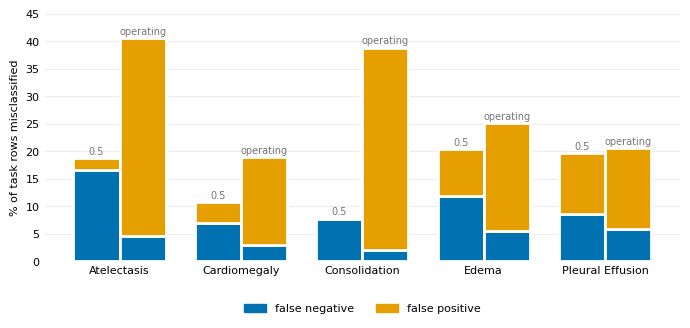

In [7]:
fig, ax = plt.subplots(figsize=(7, 3.4))
x = np.arange(len(TASKS)); w = .38
for i, (name, off) in enumerate(zip(THR_SETS, (-w/2, w/2))):
    c = conf[name]
    ax.bar(x + off, 100 * c['FN'] / c['n'], w, color=C_FN, **GAP)
    ax.bar(x + off, 100 * c['FP'] / c['n'], w, bottom=100 * c['FN'] / c['n'],
           color=C_FP, **GAP)
    for xi, v in zip(x + off, c['error %']):
        ax.text(xi, v + .6, name, ha='center', fontsize=7, color='#767676')

ax.set_ylim(0, 45)
ax.set_xticks(x); ax.set_xticklabels(TASKS, fontsize=8)
ax.set_ylabel('% of task rows misclassified', fontsize=8)
ax.tick_params(labelsize=8, length=0)
ax.grid(axis='y', color='#EDEDED', lw=.8); ax.set_axisbelow(True)
for s in ax.spines.values():
    s.set_visible(False)
ax.legend([plt.Rectangle((0, 0), 1, 1, color=k) for k in (C_FN, C_FP)],
          ['false negative', 'false positive'], frameon=False, fontsize=8, ncol=2,
          loc='upper center', bbox_to_anchor=(.5, -.13))
plt.tight_layout()